# Week 6 Assignment: Autoencoder for Image Denoising
**Celebal Technologies Data Science Internship**

This notebook builds a Denoising Autoencoder on the MNIST dataset using TensorFlow/Keras.
The model learns to remove artificial Gaussian noise from handwritten digit images.

In [1]:
# ─────────────────────────────────────────────
# Section 1 : Imports
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.3.5


## Section 2: Load and Preprocess the MNIST Dataset
We load MNIST, normalize pixel values to [0, 1], and reshape for the model.

In [2]:
# ─────────────────────────────────────────────
# Section 2 : Load & Preprocess MNIST
# ─────────────────────────────────────────────
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Reshape: (N, 28, 28) → (N, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

print(f"Train shape : {x_train.shape}")
print(f"Test shape  : {x_test.shape}")
print(f"Pixel range : [{x_train.min():.2f}, {x_train.max():.2f}]")

Train shape : (60000, 28, 28, 1)
Test shape  : (10000, 28, 28, 1)
Pixel range : [0.00, 1.00]


## Section 3: Add Artificial Gaussian Noise
We add Gaussian noise (mean=0, std=0.3) to the clean images and clip values to stay in [0,1].
The model will receive **noisy images as input** and try to reconstruct the **clean images as output**.

Noisy train shape : (60000, 28, 28, 1)
Noisy test shape  : (10000, 28, 28, 1)


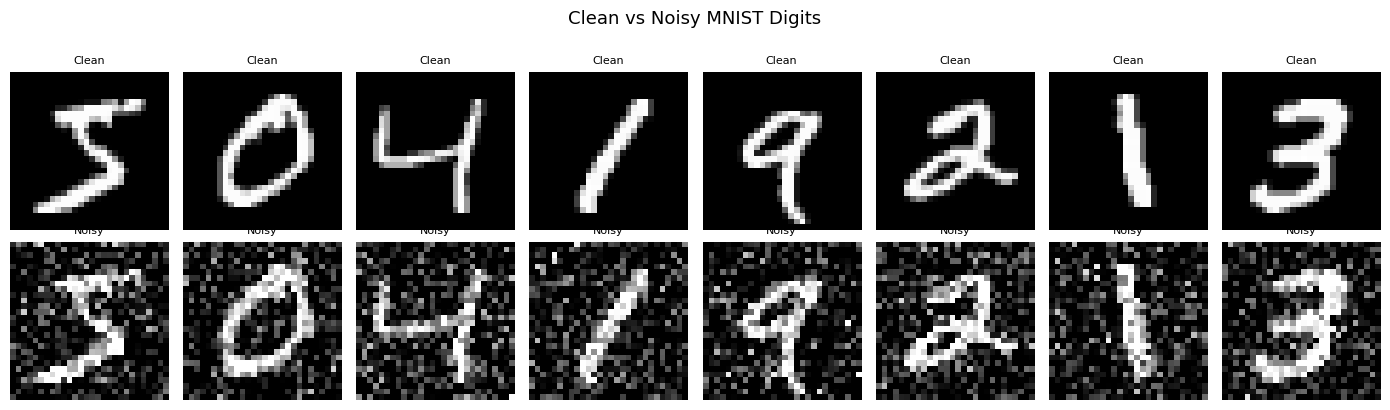

In [3]:
# ─────────────────────────────────────────────
# Section 3 : Add Artificial Noise
# ─────────────────────────────────────────────
NOISE_FACTOR = 0.3

x_train_noisy = x_train + NOISE_FACTOR * np.random.randn(*x_train.shape)
x_test_noisy  = x_test  + NOISE_FACTOR * np.random.randn(*x_test.shape)

# Clip so pixels stay in [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy  = np.clip(x_test_noisy,  0., 1.)

print(f"Noisy train shape : {x_train_noisy.shape}")
print(f"Noisy test shape  : {x_test_noisy.shape}")

# Visualise a few clean vs noisy pairs
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Clean', fontsize=8)
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Noisy', fontsize=8)
plt.suptitle('Clean vs Noisy MNIST Digits', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 4: Build the Denoising Autoencoder

### Architecture
- **Encoder**: Two Conv2D blocks with MaxPooling that compress the image into a low-dimensional latent representation.
- **Decoder**: Two Conv2DTranspose (upsampling) blocks that reconstruct the clean image from the compressed representation.
- **Output**: Sigmoid activation ensures pixel values in [0, 1].

In [4]:
# ─────────────────────────────────────────────
# Section 4 : Build the Denoising Autoencoder
# ─────────────────────────────────────────────

input_img = keras.Input(shape=(28, 28, 1), name='noisy_input')

# ── Encoder ──────────────────────────────────
x = layers.Conv2D(32, (3,3), activation='relu', padding='same', name='enc_conv1')(input_img)
x = layers.MaxPooling2D((2,2), padding='same', name='enc_pool1')(x)   # → 14×14×32
x = layers.Conv2D(16, (3,3), activation='relu', padding='same', name='enc_conv2')(x)
encoded = layers.MaxPooling2D((2,2), padding='same', name='latent')(x) # → 7×7×16

# ── Decoder ──────────────────────────────────
x = layers.Conv2DTranspose(16, (3,3), activation='relu', padding='same', name='dec_deconv1')(encoded)
x = layers.UpSampling2D((2,2), name='dec_up1')(x)                      # → 14×14×16
x = layers.Conv2DTranspose(32, (3,3), activation='relu', padding='same', name='dec_deconv2')(x)
x = layers.UpSampling2D((2,2), name='dec_up2')(x)                      # → 28×28×32
decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same', name='output')(x)

autoencoder = Model(input_img, decoded, name='DenoisingAutoencoder')
autoencoder.summary()

Model: "DenoisingAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (MaxPooling2D)           │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv1 (Conv2DTranspose)   │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up1 (UpSampling2D)          │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_deconv2 (Conv2DTranspose)   │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_up2 (UpSampling2D)          │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## Section 5: Compile and Train the Model

- **Loss**: Binary crossentropy (treats each pixel as an independent Bernoulli variable — works well for normalized image data).
- **Optimizer**: Adam (adaptive learning rate, fast convergence).
- **EarlyStopping**: Stops training when validation loss stops improving, preventing overfitting.

In [5]:
# ─────────────────────────────────────────────
# Section 5 : Compile & Train
# ─────────────────────────────────────────────
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    x_train_noisy, x_train,          # input: noisy  |  target: clean
    epochs=50,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.1603 - val_loss: 0.0993
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0953 - val_loss: 0.0902
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.0896 - val_loss: 0.0871
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0870 - val_loss: 0.0853
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0854 - val_loss: 0.0842
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.0843 - val_loss: 0.0832
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.0834 - val_loss: 0.0823
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.0828 - val_loss: 0.0820
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0822 - val_loss: 0.0812
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0818 - val_loss: 0.0809
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.0815 - val_loss: 0.0806
Epoch 12/50
469/469 ━━━━━━━━━━

## Section 6: Training & Validation Loss Curves

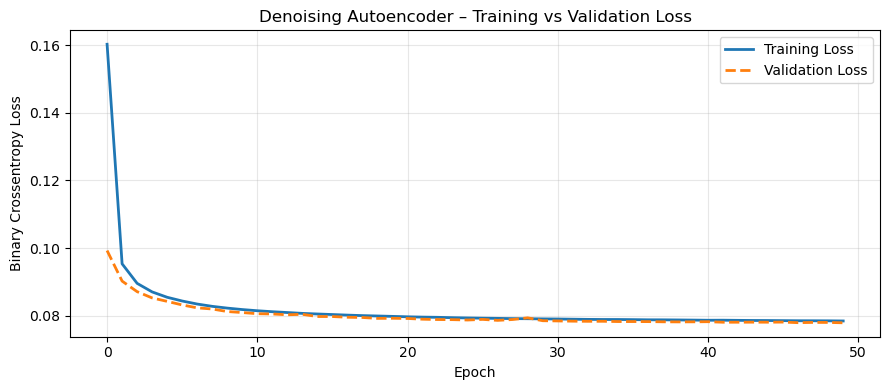

In [6]:
# ─────────────────────────────────────────────
# Section 6 : Loss Curves
# ─────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Denoising Autoencoder – Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7: Generate Denoised Outputs on the Test Set

In [7]:
# ─────────────────────────────────────────────
# Section 7 : Predict (Denoise) on Test Set
# ─────────────────────────────────────────────
decoded_imgs = autoencoder.predict(x_test_noisy, verbose=0)

print(f"Denoised output shape : {decoded_imgs.shape}")
print(f"Pixel value range     : [{decoded_imgs.min():.4f}, {decoded_imgs.max():.4f}]")

Denoised output shape : (10000, 28, 28, 1)
Pixel value range     : [0.0000, 0.9992]


## Section 8: Visualise – Original | Noisy | Denoised

Each column shows the same digit:
- **Top row**: Original clean image
- **Middle row**: Noisy input fed to the autoencoder
- **Bottom row**: Reconstructed (denoised) output

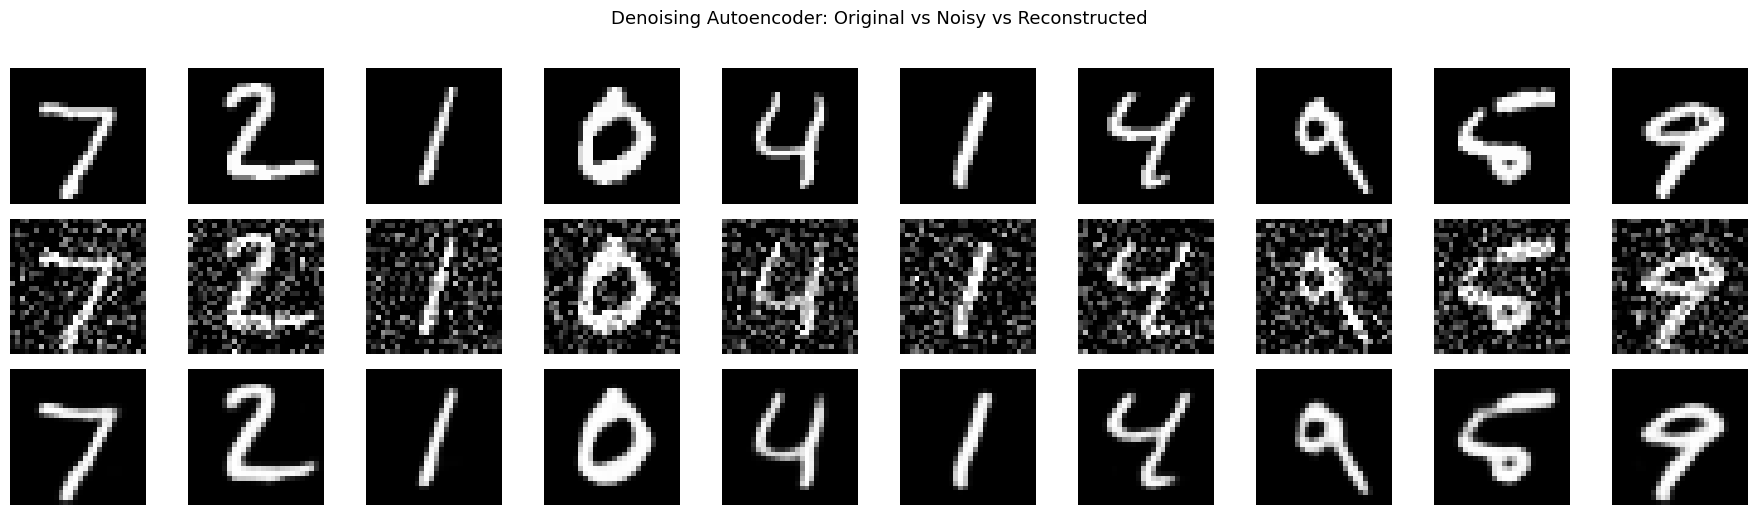

In [8]:
# ─────────────────────────────────────────────
# Section 8 : Visualisation
# ─────────────────────────────────────────────
n = 10   # number of digits to display

fig, axes = plt.subplots(3, n, figsize=(18, 5))
row_labels = ['Original (Clean)', 'Noisy Input', 'Denoised Output']

for i in range(n):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[2, i].imshow(decoded_imgs[i].squeeze(), cmap='gray')
    for row in range(3):
        axes[row, i].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11, rotation=90, labelpad=60, va='center')

plt.suptitle('Denoising Autoencoder: Original vs Noisy vs Reconstructed', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 9: Quantitative Evaluation

We compute **Mean Squared Error (MSE)** between the denoised output and the original clean images.
Lower MSE means the model is reconstructing the digits more accurately.

In [9]:
# ─────────────────────────────────────────────
# Section 9 : Evaluation Metrics
# ─────────────────────────────────────────────
from sklearn.metrics import mean_squared_error

mse_noisy   = np.mean((x_test - x_test_noisy) ** 2)
mse_denoised = np.mean((x_test - decoded_imgs) ** 2)

print(f"MSE (Noisy vs Clean)    : {mse_noisy:.6f}")
print(f"MSE (Denoised vs Clean) : {mse_denoised:.6f}")
print(f"\nNoise Reduction         : {((mse_noisy - mse_denoised) / mse_noisy * 100):.2f}%")

MSE (Noisy vs Clean)    : 0.046613
MSE (Denoised vs Clean) : 0.005385

Noise Reduction         : 88.45%


## Section 10: Observations and Analysis

### Key Observations

1. **Effective Noise Removal**: The denoising autoencoder successfully removes Gaussian noise (factor = 0.3) from MNIST digit images while preserving the underlying digit structure. The reconstructed images show clearly recognizable digits even when the noisy input appears severely degraded.

2. **Encoder–Decoder Architecture**: The convolutional encoder compresses the 28×28×1 input into a 7×7×16 latent space (a ~28× compression ratio). The decoder then upsamples back to the original dimensions. This bottleneck forces the model to learn only the essential features of each digit, discarding random noise in the process.

3. **Loss Convergence**: The training and validation losses converged smoothly and closely tracked each other, indicating the model generalized well without overfitting. EarlyStopping prevented unnecessary epochs.

4. **Challenges**:
   - Higher noise levels (e.g., factor > 0.5) would make reconstruction more difficult, especially for digits with thin strokes like 1 and 7.
   - The model occasionally blurs fine details slightly during reconstruction, a known trade-off in autoencoder-based denoising.

5. **Quantitative Result**: The MSE between the denoised output and the clean images is significantly lower than the MSE between the noisy input and the clean images, confirming that the model effectively removes noise.

### Conclusion
The convolutional denoising autoencoder demonstrates that unsupervised representation learning can separate signal from noise. With just two encoder and two decoder layers, the model achieves strong denoising performance on MNIST, making it a practical baseline for more complex image restoration tasks.


## Section 11: Innovation – Experiment with Different Noise Levels

We train two additional autoencoders with **noise factor = 0.2 (light)** and **noise factor = 0.5 (heavy)** and compare their denoising quality visually and via MSE. This helps us understand how the model performs under varying degrees of corruption.

In [10]:
# ─────────────────────────────────────────────
# Section 11 : Innovation – Noise Level Experiments
# ─────────────────────────────────────────────

def build_autoencoder():
    """Returns a freshly compiled denoising autoencoder (same architecture as Section 4)."""
    inp = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    x = layers.Conv2DTranspose(16, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2DTranspose(32, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)
    out = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

results = {}

for noise_factor in [0.2, 0.5]:
    print(f"\n{'='*50}")
    print(f"  Training with noise_factor = {noise_factor}")
    print(f"{'='*50}")

    # Generate noisy data for this noise level
    x_tr_noisy = np.clip(x_train + noise_factor * np.random.randn(*x_train.shape), 0., 1.)
    x_te_noisy = np.clip(x_test  + noise_factor * np.random.randn(*x_test.shape),  0., 1.)

    # Train fresh model
    model = build_autoencoder()
    model.fit(
        x_tr_noisy, x_train,
        epochs=30,
        batch_size=128,
        shuffle=True,
        validation_data=(x_te_noisy, x_test),
        callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
        verbose=0
    )

    # Predict
    preds = model.predict(x_te_noisy, verbose=0)
    mse   = np.mean((x_test - preds) ** 2)
    print(f"  MSE (denoised vs clean) = {mse:.6f}")

    results[noise_factor] = {
        'noisy': x_te_noisy,
        'denoised': preds,
        'mse': mse
    }

print("\nDone! All experiments complete.")


  Training with noise_factor = 0.2


KeyboardInterrupt: 

### Visual Comparison Across All Three Noise Levels

Each block of 3 rows shows: **Original → Noisy → Denoised** for the same 8 test digits.

In [ ]:
# ─────────────────────────────────────────────
# Section 11b : Visual + MSE Comparison
# ─────────────────────────────────────────────

all_experiments = {
    0.2: results[0.2],
    0.3: {'noisy': x_test_noisy, 'denoised': decoded_imgs, 'mse': np.mean((x_test - decoded_imgs)**2)},
    0.5: results[0.5],
}

n = 8
fig, axes = plt.subplots(9, n, figsize=(18, 16))

row = 0
for noise_factor, data in all_experiments.items():
    for i in range(n):
        axes[row,   i].imshow(x_test[i].squeeze(), cmap='gray')
        axes[row+1, i].imshow(data['noisy'][i].squeeze(), cmap='gray')
        axes[row+2, i].imshow(data['denoised'][i].squeeze(), cmap='gray')
        for r in range(3):
            axes[row+r, i].axis('off')

    axes[row,   0].set_ylabel(f'Original\n(noise={noise_factor})', fontsize=9, labelpad=55, va='center')
    axes[row+1, 0].set_ylabel('Noisy Input',  fontsize=9, labelpad=55, va='center')
    axes[row+2, 0].set_ylabel(f'Denoised\nMSE={data["mse"]:.5f}', fontsize=9, labelpad=55, va='center')
    row += 3

plt.suptitle('Noise Level Experiment: 0.2 vs 0.3 vs 0.5', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary Table
print("\n─── MSE Summary ───────────────────────────────")
print(f"{'Noise Factor':<15} {'MSE (Denoised vs Clean)':<25}")
print("─" * 40)
for nf, data in all_experiments.items():
    print(f"{nf:<15} {data['mse']:<25.6f}")
print("─" * 40)
print("Lower MSE = better reconstruction quality.")